# Forecasting Harga Bitcoin (BTC-USD): LSTM vs Prophet
Notebook ini memuat proses lengkap: pembersihan data, eksplorasi (EDA), pemeriksaan stasioneritas, pembagian data kronologis, pemodelan (Prophet dan LSTM), serta evaluasi.

In [ ]:
#pip install tensorflow

## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import adfuller

## 2. Pembersihan dan Pemuatan Data

In [ ]:
df = pd.read_csv('btc_3y.csv', skiprows=[1, 2], parse_dates=['Price'])
df = df.rename(columns={'Price': 'Date'}).set_index('Date')
df = df.sort_index()

print("Shape:", df.shape)
print("Range:", df.index.min().date(), "->", df.index.max().date())
df[['Close']].head()

Shape: (1111, 5)
Range: 2023-06-01 -> 2026-06-15


,Close
Date,
2023-06-01,26819.972656
2023-06-02,27249.589844
2023-06-03,27075.128906
2023-06-04,27119.066406
2023-06-05,25760.097656


## 3. Eksplorasi Data (EDA)
Visualisasi deret waktu harga penutupan untuk mengamati tren dan pola.

In [ ]:
# Plot harga penutupan sepanjang periode
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='orange')
plt.title('Harga Penutupan BTC-USD (2023-2026)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.grid(True, alpha=0.3)
plt.show()

# Statistik deskriptif
print(df['Close'].describe())
print("\nHarga tertinggi:", round(df['Close'].max(), 2), "pada", df['Close'].idxmax().date())

In [ ]:
# Moving average untuk melihat tren dan volatilitas
df['MA30'] = df['Close'].rolling(30).mean()
df['MA90'] = df['Close'].rolling(90).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close', alpha=0.4)
plt.plot(df.index, df['MA30'], label='MA 30 hari', color='red')
plt.plot(df.index, df['MA90'], label='MA 90 hari', color='green')
plt.legend()
plt.title('BTC Close + Moving Average')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Pembagian Data Kronologis
Data uji diambil 30 hari terakhir sesuai horizon peramalan. Tidak diacak untuk mencegah kebocoran data.

In [ ]:
test_size = 30
train = df['Close'][:-test_size]
test = df['Close'][-test_size:]

print(f"Train: {len(train)} hari ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test : {len(test)} hari ({test.index.min().date()} -> {test.index.max().date()})")

Train: 1081 hari (2023-06-01 -> 2026-05-16)
Test : 30 hari (2026-05-17 -> 2026-06-15)


## 5. Pemeriksaan Stasioneritas (Uji ADF)
Uji Augmented Dickey-Fuller. Data stasioner jika p-value < 0,05.

In [ ]:
def uji_adf(series, label):
    hasil = adfuller(series.dropna())
    status = 'STASIONER' if hasil[1] <= 0.05 else 'NON-stasioner'
    print(f'=== {label} ===')
    print(f'ADF Statistic : {hasil[0]:.4f}')
    print(f'p-value       : {hasil[1]:.4f}  -> {status}')
    print()

uji_adf(train, 'Close (level)')
uji_adf(np.log(train), 'log(Close)')
uji_adf(np.log(train).diff(), 'Log return (differencing orde 1)')

## 6. Fungsi Evaluasi

In [ ]:
def evaluate(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f'=== {name} ===')
    print(f'MAE  : {mae:,.2f}')
    print(f'RMSE : {rmse:,.2f}')
    print(f'MAPE : {mape:.2f}%\n')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

## 7. Pemodelan Prophet

In [ ]:
train_prophet = train.reset_index()
train_prophet.columns = ['ds', 'y']
train_prophet.head()

,ds,y
0,2023-06-01,26819.972656
1,2023-06-02,27249.589844
2,2023-06-03,27075.128906
3,2023-06-04,27119.066406
4,2023-06-05,25760.097656


In [ ]:
m_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
m_prophet.fit(train_prophet)

future = m_prophet.make_future_dataframe(periods=test_size)
forecast = m_prophet.predict(future)

fc_prophet = pd.Series(forecast['yhat'][-test_size:].values, index=test.index)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1106,2026-06-11,68848.826334,62416.512835,75426.565105
1107,2026-06-12,68420.760429,62222.649861,74816.810759
1108,2026-06-13,67881.349089,61344.885025,74209.202765
1109,2026-06-14,67454.424838,60714.969426,73724.125055
1110,2026-06-15,67255.269898,60564.978919,73877.837876


In [ ]:
res_prophet = evaluate(test.values, fc_prophet.values, 'Prophet')

=== Prophet ===
MAE  : 4,243.34
RMSE : 5,035.60
MAPE : 6.37%



## 8. Pemodelan LSTM (Direct Multi-step + Log Return)

In [ ]:
train_logret = np.log(train).diff().dropna()

scaler = StandardScaler()
ret_scaled = scaler.fit_transform(train_logret.values.reshape(-1, 1))

last_price = train.iloc[-1]

In [ ]:
def create_sequences_multi(data, window, horizon):
    X, y = [], []
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i-window:i, 0])
        y.append(data[i:i+horizon, 0])
    return np.array(X), np.array(y)

window, horizon = 60, 30
X_train, y_train = create_sequences_multi(ret_scaled, window, horizon)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
print("X_train:", X_train.shape, "y_train:", y_train.shape)

X_train: (991, 60, 1) y_train: (991, 30)


In [ ]:
model_lstm = Sequential([
    LSTM(32, return_sequences=False, input_shape=(window, 1)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(horizon)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,390 (21.05 KB)

 Trainable params: 5,390 (21.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.9875 - val_loss: 1.5132
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9866 - val_loss: 1.5132
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9862 - val_loss: 1.5134
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9861 - val_loss: 1.5136
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.9860 - val_loss: 1.5140
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9857 - val_loss: 1.5142
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.9859 - val_loss: 1.5146
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9855 - val_loss: 1.5151
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.9854 - val_loss: 1.5154
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9855 - val_loss: 1.5157
Epoch 11/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.9852 - val_loss: 1.5161


In [ ]:
last_seq = ret_scaled[-window:].reshape(1, window, 1)
pred_scaled = model_lstm.predict(last_seq, verbose=0)[0]
pred_logret = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

fc_lstm = last_price * np.exp(np.cumsum(pred_logret))
fc_lstm = pd.Series(fc_lstm, index=test.index)
fc_lstm.head()

,0
Date,
2026-05-17,78290.017547
2026-05-18,78398.581452
2026-05-19,78425.247414
2026-05-20,78487.259981
2026-05-21,78573.488929


In [ ]:
res_lstm = evaluate(test.values, fc_lstm.values, 'LSTM (Direct+Return)')

=== LSTM (Direct+Return) ===
MAE  : 9,541.19
RMSE : 11,773.12
MAPE : 14.66%



In [ ]:
hasil = pd.DataFrame([res_lstm, res_prophet]).round(2)
hasil

,Model,MAE,RMSE,MAPE
0,LSTM (Direct+Return),9541.19,11773.12,14.66
1,Prophet,4243.34,5035.60,6.37


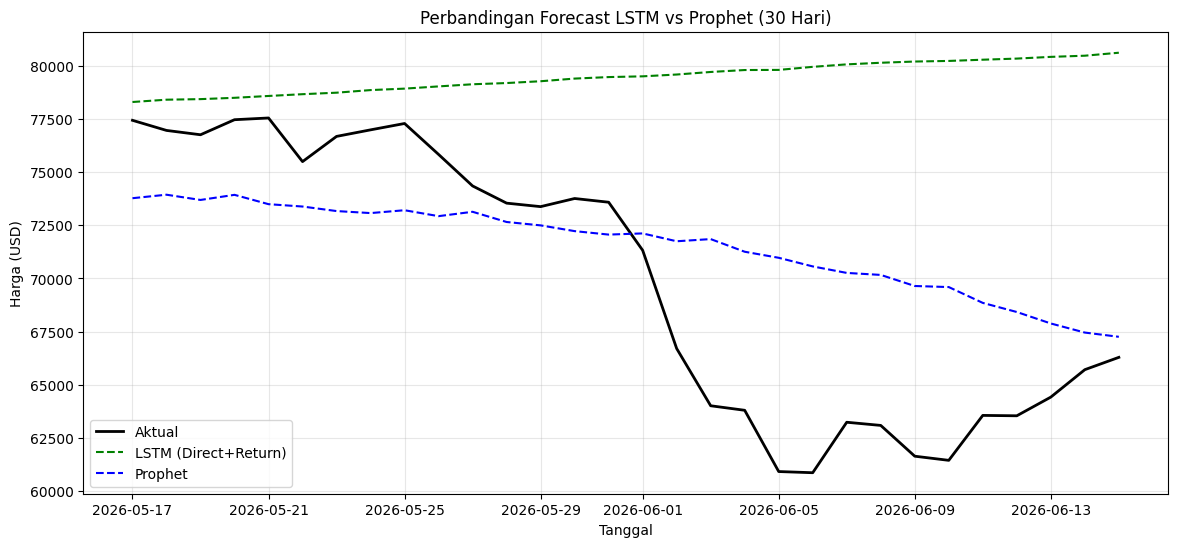

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label='Aktual', color='black', linewidth=2)
plt.plot(fc_lstm.index, fc_lstm, label='LSTM (Direct+Return)', color='green', linestyle='--')
plt.plot(fc_prophet.index, fc_prophet, label='Prophet', color='blue', linestyle='--')
plt.title('Perbandingan Forecast LSTM vs Prophet (30 Hari)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Pemodelan LSTM Multivariate (Close, Volume, High, Low)

In [ ]:
# ambil 4 kolom, hitung log return semuanya (biar skalanya stabil)
feat_cols = ['Close', 'Volume', 'High', 'Low']
train_feat = df[feat_cols][:-test_size].copy()

# log return tiap kolom (volume pakai pct_change biar aman dari nilai 0)
train_ret = pd.DataFrame(index=train_feat.index)
train_ret['Close'] = np.log(train_feat['Close']).diff()
train_ret['High']  = np.log(train_feat['High']).diff()
train_ret['Low']   = np.log(train_feat['Low']).diff()
train_ret['Volume'] = train_feat['Volume'].pct_change()
train_ret = train_ret.dropna()

# scaling semua fitur
scaler = StandardScaler()
feat_scaled = scaler.fit_transform(train_ret.values)   # shape: (n, 4)

# scaler khusus buat balikin return Close (kolom 0) nanti
close_mean = train_ret['Close'].mean()
close_std = train_ret['Close'].std()

last_price = train.iloc[-1]
print("Fitur:", train_ret.columns.tolist(), "| shape:", feat_scaled.shape)

Fitur: ['Close', 'High', 'Low', 'Volume'] | shape: (1080, 4)


In [ ]:
# X: 60 hari x 4 fitur. y: 30 hari return Close (kolom 0 saja)
def create_sequences_multivar(data, window, horizon):
    X, y = [], []
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i-window:i, :])        # semua fitur
        y.append(data[i:i+horizon, 0])       # target cuma return Close
    return np.array(X), np.array(y)

window, horizon = 60, 30
X_train, y_train = create_sequences_multivar(feat_scaled, window, horizon)
print("X_train:", X_train.shape, "y_train:", y_train.shape)

X_train: (991, 60, 4) y_train: (991, 30)


In [ ]:
n_features = X_train.shape[2]   # 4

model_lstm = Sequential([
    LSTM(64, return_sequences=False, input_shape=(window, n_features)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(horizon)
])
model_lstm.compile(optimizer='adam', loss='mae')   # ganti ke MAE, lebih robust
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,734 (80.99 KB)

 Trainable params: 20,734 (80.99 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.7055 - val_loss: 0.8350
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.7045 - val_loss: 0.8339
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.7037 - val_loss: 0.8333
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7034 - val_loss: 0.8327
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7033 - val_loss: 0.8324
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7032 - val_loss: 0.8324
Epoch 7/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7029 - val_loss: 0.8326
Epoch 8/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7027 - val_loss: 0.8319
Epoch 9/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.7027 - val_loss: 0.8321
Epoch 10/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.7022 - val_loss: 0.8317
Epoch 11/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.7022 - val_loss: 0.8318
Epoch 12/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

In [ ]:
# input: 60 hari terakhir semua fitur
last_seq = feat_scaled[-window:].reshape(1, window, n_features)
pred_scaled = model_lstm.predict(last_seq, verbose=0)[0]

# balikin return Close dari hasil scaling (pakai mean/std kolom Close)
pred_logret = pred_scaled * close_std + close_mean

# rekonstruksi harga
fc_lstm = last_price * np.exp(np.cumsum(pred_logret))
fc_lstm = pd.Series(fc_lstm, index=test.index)
fc_lstm.head()

,0
Date,
2026-05-17,78218.607101
2026-05-18,78443.563539
2026-05-19,78585.343309
2026-05-20,78823.746674
2026-05-21,78749.778492


In [ ]:
res_lstm = evaluate(test.values, fc_lstm.values, 'LSTM Multivariate')
hasil = pd.DataFrame([res_lstm, res_prophet]).round(2)
hasil

=== LSTM Multivariate ===
MAE  : 9,451.62
RMSE : 11,671.22
MAPE : 14.52%



,Model,MAE,RMSE,MAPE
0,LSTM Multivariate,9451.62,11671.22,14.52
1,Prophet,4243.34,5035.60,6.37


## 10. Kesimpulan
Prophet menjadi model terbaik dengan MAPE 6,37 persen (di bawah target 10 persen), mengungguli LSTM. Model kompleks tidak selalu unggul pada data terbatas dan volatil.